# Detection probe analysis — tfv6_visiononly

Reads `detection_probe.tsv` from the 3×3 matrix runs and computes per-condition perception statistics: detection rate, mean confidence, brake-window comparison.

Each TSV row is one simulation tick (20 Hz, so 300 ticks = 15 s). Columns:
- `step`: tick index
- `score`: confidence of the detected front vehicle (0.0 if no vehicle detected ahead this tick)
- `x, y, w, h`: bbox in vehicle frame (meters; +x forward, +y left)
- `class`: detected object class id

A row with `score=0` means the agent's internal detection head produced no bbox in the front-vehicle window (`x ∈ [0.5, 60] m`, `|y| ≤ 4 m`). See `detection_probe.py` for filter definition.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to the matrix runs (relative to this notebook)
BASE = Path("../../experiments/carla_scenarios/matrix_3x3_20260429_with_probe")

RUNS = {
    "none": "none_tfv6_visiononly_20260429_133541",
    "raw":  "raw_tfv6_visiononly_20260429_135227",
    "camo": "camouflaged_tfv6_visiononly_20260429_140054",
}

# Brake event happens at t = 10 s = step 200 (sim @ 20 Hz)
BRAKE_STEP = 200
WINDOW = (180, 260)  # critical perception window: ~9-13 s

data = {
    cond: pd.read_csv(BASE / run / "detection_probe.tsv", sep="\t")
    for cond, run in RUNS.items()
}

for cond, df in data.items():
    print(f"{cond}: {len(df)} ticks")

none: 300 ticks
raw: 300 ticks
camo: 300 ticks


## Aggregate statistics

In [2]:
def stats(df, label):
    n = len(df)
    detected = df[df["score"] > 0]
    n_det = len(detected)
    return {
        "condition": label,
        "n_ticks": n,
        "n_detected": n_det,
        "detection_rate": f"{n_det / n * 100:.1f}%",
        "mean_score_when_detected": round(detected["score"].mean(), 3) if n_det else 0.0,
        "std_score_when_detected": round(detected["score"].std(), 3) if n_det > 1 else 0.0,
    }

summary_full = pd.DataFrame([stats(df, c) for c, df in data.items()])
print("=== Full run (300 ticks = 15 s) ===")
summary_full

=== Full run (300 ticks = 15 s) ===


,condition,n_ticks,n_detected,detection_rate,mean_score_when_detected,std_score_when_detected
0,none,300,76,25.3%,0.498,0.022
1,raw,300,2,0.7%,0.518,0.003
2,camo,300,23,7.7%,0.321,0.016


In [3]:
summary_window = pd.DataFrame([
    stats(df[(df["step"] >= WINDOW[0]) & (df["step"] <= WINDOW[1])], c)
    for c, df in data.items()
])
print(f"=== Brake window (steps {WINDOW[0]}-{WINDOW[1]}, ~{WINDOW[0]/20:.0f}-{WINDOW[1]/20:.0f} s) ===")
summary_window

=== Brake window (steps 180-260, ~9-13 s) ===


,condition,n_ticks,n_detected,detection_rate,mean_score_when_detected,std_score_when_detected
0,none,81,37,45.7%,0.491,0.027
1,raw,81,2,2.5%,0.518,0.003
2,camo,81,11,13.6%,0.312,0.009


## Score timeline — score vs simulation time, per condition

Each marker is one detected tick (score > 0). The vertical dashed line marks the brake event. The shaded band is the brake window (180-260).

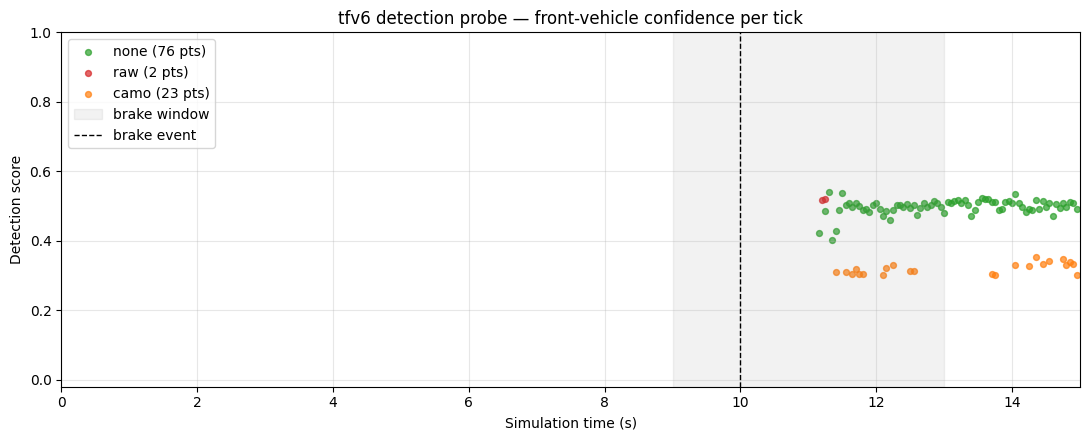

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = {"none": "tab:green", "raw": "tab:red", "camo": "tab:orange"}

for cond, df in data.items():
    detected = df[df["score"] > 0]
    ax.scatter(detected["step"] / 20, detected["score"],
               s=18, alpha=0.7, label=f"{cond} ({len(detected)} pts)",
               color=colors[cond])

ax.axvspan(WINDOW[0]/20, WINDOW[1]/20, alpha=0.10, color="gray", label="brake window")
ax.axvline(BRAKE_STEP/20, color="black", linestyle="--", linewidth=1, label="brake event")
ax.set_xlabel("Simulation time (s)")
ax.set_ylabel("Detection score")
ax.set_title("tfv6 detection probe — front-vehicle confidence per tick")
ax.set_ylim(-0.02, 1.0)
ax.set_xlim(0, 15)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Detection rate per condition (bar chart)

Side-by-side: full run vs brake window. The brake window is the perceptually critical interval — if the agent doesn't see the leader here, it cannot react in time.

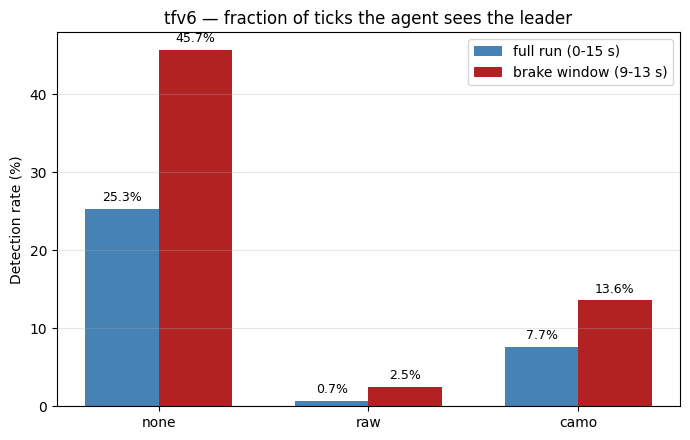

In [5]:
labels = list(data.keys())
rates_full = [len(df[df["score"] > 0]) / len(df) * 100 for df in data.values()]
rates_win = [
    len(df[(df["score"] > 0) & (df["step"] >= WINDOW[0]) & (df["step"] <= WINDOW[1])])
    / len(df[(df["step"] >= WINDOW[0]) & (df["step"] <= WINDOW[1])]) * 100
    for df in data.values()
]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width/2, rates_full, width, label="full run (0-15 s)", color="steelblue")
ax.bar(x + width/2, rates_win,  width, label="brake window (9-13 s)", color="firebrick")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Detection rate (%)")
ax.set_title("tfv6 — fraction of ticks the agent sees the leader")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, (rf, rw) in enumerate(zip(rates_full, rates_win)):
    ax.text(i - width/2, rf + 1, f"{rf:.1f}%", ha="center", fontsize=9)
    ax.text(i + width/2, rw + 1, f"{rw:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Conclusions

- In the **brake window** (steps 180-260, the critical 4 s where collision avoidance happens), tfv6's detection rate drops from **~46% (none)** to **~3% (raw)** — a roughly 18× suppression of the agent's internal perception of the leader.
- Camouflaged patch shows an intermediate effect: ~14% detection rate in the brake window, with mean score ~0.31 (vs 0.49 baseline) — bboxes that survive are weaker.
- Driving outcome did not change (tfv6 crashes in all conditions), but this is because tfv6 already underperformed in the baseline (only 46% detection rate even in `none`). The patch pushes a perception system that was already brittle into total blindness.
- This is the *measurable evidence inside the agent* that Tonella requested at the 2026-04-24 meeting: the patch trained on YOLO **does** transfer to tfv6's internal detection head, even though closed-loop behavior masks the effect.